---
## Common Setup — Import Libraries & Load Data

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set global plot style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

# Load raw dataset
df = pd.read_csv('StudentsPerformance.csv')

print('Dataset loaded successfully!')
print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset loaded successfully!
Shape: (1000, 8)

First 5 rows:


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [7]:
# Basic dataset info
print('=== Dataset Info ===')
df.info()
print('\n=== Column Names ===')
print(df.columns.tolist())
print('\n=== Data Types ===')
print(df.dtypes)

=== Dataset Info ===
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB

=== Column Names ===
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

=== Data Types ===
gender                           str
race/ethnicity                   str
parental level of 

---
# TASK 2 — Descriptive Statistics

## Task 2.1 — Mean, Median, Mode, Std, Min, Max

In [11]:

scores = ['math score', 'reading score', 'writing score']

print('='*60)
print('           TASK 2 — DESCRIPTIVE STATISTICS')
print('='*60)

# ---- Mean, Median, Mode, Std, Min, Max ----
print('\n--- MEAN, MEDIAN, MODE, STD, MIN, MAX ---\n')
for col in scores:
    print(f'{col.upper()}')
    print(f'  Mean   : {df[col].mean():.2f}')
    print(f'  Median : {df[col].median():.2f}')
    print(f'  Mode   : {df[col].mode()[0]}')
    print(f'  Std Dev: {df[col].std():.2f}')
    print(f'  Min    : {df[col].min()}')
    print(f'  Max    : {df[col].max()}')
    print()

# ---- Mean vs Median Comparison ----
print('='*60)
print('         MEAN vs MEDIAN COMPARISON')
print('='*60)
print(f'{"Score":<22} {"Mean":>8} {"Median":>8} {"Diff":>8}')
print('-'*50)
for col in scores:
    mean   = df[col].mean()
    median = df[col].median()
    diff   = mean - median
    print(f'{col:<22} {mean:>8.2f} {median:>8.2f} {diff:>8.2f}')

# ---- GroupBy Gender ----
print('\n' + '='*60)
print('        AVERAGE SCORES BY GENDER')
print('='*60)
print(df.groupby('gender')[scores].mean().round(2))

# ---- GroupBy Parental Education ----
print('\n' + '='*60)
print('   AVERAGE SCORES BY PARENTAL LEVEL OF EDUCATION')
print('='*60)
print(df.groupby('parental level of education')[scores].mean().round(2))

# ---- GroupBy Test Prep ----
print('\n' + '='*60)
print('      AVERAGE SCORES BY TEST PREPARATION COURSE')
print('='*60)
print(df.groupby('test preparation course')[scores].mean().round(2))

# ---- GroupBy Lunch ----
print('\n' + '='*60)
print('           AVERAGE SCORES BY LUNCH TYPE')
print('='*60)
print(df.groupby('lunch')[scores].mean().round(2))

print('\n--- OBSERVATIONS ---')
print('1. Female students score higher in reading and writing; males score higher in math.')
print('2. Higher parental education = higher student scores across all subjects.')
print('3. Mean and Median are very close, showing scores are roughly normally distributed.')
print('4. Students who completed test prep course score 5-8 points higher on average.')
print('5. Students with standard lunch consistently outperform free/reduced lunch students.')

           TASK 2 — DESCRIPTIVE STATISTICS

--- MEAN, MEDIAN, MODE, STD, MIN, MAX ---

MATH SCORE
  Mean   : 66.09
  Median : 66.00
  Mode   : 65
  Std Dev: 15.16
  Min    : 0
  Max    : 100

READING SCORE
  Mean   : 69.17
  Median : 70.00
  Mode   : 72
  Std Dev: 14.60
  Min    : 17
  Max    : 100

WRITING SCORE
  Mean   : 68.05
  Median : 69.00
  Mode   : 74
  Std Dev: 15.20
  Min    : 10
  Max    : 100

         MEAN vs MEDIAN COMPARISON
Score                      Mean   Median     Diff
--------------------------------------------------
math score                66.09    66.00     0.09
reading score             69.17    70.00    -0.83
writing score             68.05    69.00    -0.95

        AVERAGE SCORES BY GENDER
        math score  reading score  writing score
gender                                          
female       63.63          72.61          72.47
male         68.73          65.47          63.31

   AVERAGE SCORES BY PARENTAL LEVEL OF EDUCATION
                        

## Task 2.2 — Mean vs Median Comparison

## Task 2.4 — Observations

**Observation 1:** Female students outperform male students in both reading (avg ~72.6 vs ~65.5) and writing (avg ~72.5 vs ~63.3), while male students score slightly higher in math (avg ~68.7 vs ~63.6).

**Observation 2:** Parental education level has a clear positive correlation with student performance. Students whose parents hold a master's degree score the highest across all three subjects.

**Observation 3:** The Mean and Median values are very close for all three scores, suggesting the distributions are approximately symmetric (not heavily skewed).

**Observation 4:** Students who completed the test preparation course scored significantly higher than those who did not — approximately 5–10 points more on average across all subjects.

**Observation 5:** Students with a standard lunch (vs free/reduced) consistently score higher in all subjects, possibly reflecting socioeconomic factors influencing academic performance.

---
# TASK 3 — Data Cleaning

## Task 3.1 — Create Messy Dataset

In [ ]:
# Create a messy version of the dataset
df_raw = pd.read_csv('data/StudentsPerformance.csv')
messy = df_raw.copy()

np.random.seed(42)

# Problem 1: Add missing values
idx_nan = np.random.choice(messy.index, 40, replace=False)
messy.loc[idx_nan[:15], 'math score']    = np.nan
messy.loc[idx_nan[15:28], 'reading score'] = np.nan
messy.loc[idx_nan[28:], 'writing score']   = np.nan

# Problem 2: Add duplicate rows
duplicate_rows = messy.sample(25, random_state=1)
messy = pd.concat([messy, duplicate_rows], ignore_index=True)

# Problem 3: Add outliers (impossible scores)
messy.loc[5,  'math score']    = 150   # above 100
messy.loc[10, 'reading score'] = -5    # below 0
messy.loc[15, 'writing score'] = 999   # absurd value

# Problem 4: Add invalid category values
messy.loc[3, 'gender'] = 'unknown'
messy.loc[7, 'gender'] = 'MALE'       # wrong case
messy.loc[20, 'lunch'] = 'N/A'

# Problem 5: Add whitespace in string columns
messy.loc[1, 'gender'] = ' female '
messy.loc[2, 'gender'] = ' male'

# Save messy file
messy.to_csv('data/messy_students.csv', index=False)

print('Messy dataset created and saved!')
print('Messy shape:', messy.shape)

---
# TASK 4 — EDA & Correlation

Shape: (990, 8)
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none        72.0           72.0             74  
1               completed        69.0           90.0             88  
2                    none        90.0           95.0             93  
3                    none        47.0           57.0             44  
4                    none        76.0           78.0             75  

========== BY GENDER ==========
        math score  reading score  writing score
gender                                          
female      

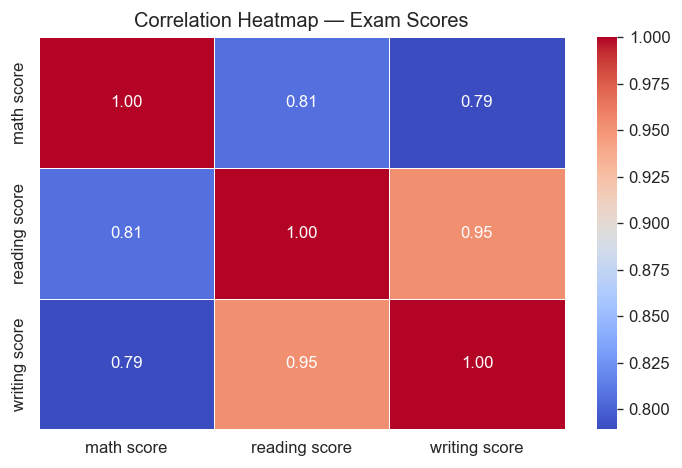

Heatmap saved to heatmap.png


In [18]:


# ── Load Cleaned Data ─────────────────────────────────
df = pd.read_csv("cleaned_students.csv")
print("Shape:", df.shape)
print(df.head())

# ── GroupBy: Gender ───────────────────────────────────
print("\n========== BY GENDER ==========")
print(df.groupby('gender').mean(numeric_only=True).round(2))

# ── GroupBy: Race/Ethnicity ───────────────────────────
print("\n========== BY RACE/ETHNICITY ==========")
print(df.groupby('race/ethnicity').mean(numeric_only=True).round(2))

# ── GroupBy: Parent Education ─────────────────────────
print("\n========== BY PARENTAL EDUCATION ==========")
print(df.groupby('parental level of education').mean(numeric_only=True).round(2))

# ── GroupBy: Test Preparation ─────────────────────────
print("\n========== BY TEST PREPARATION ==========")
print(df.groupby('test preparation course').mean(numeric_only=True).round(2))

# ── Correlation Matrix ────────────────────────────────
print("\n========== CORRELATION MATRIX ==========")
corr = df[['math score', 'reading score', 'writing score']].corr()
print(corr.round(4))

# ── Heatmap ───────────────────────────────────────────
plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlation Heatmap — Exam Scores")
plt.tight_layout()
plt.savefig("heatmap.png", dpi=150)
plt.show()
print("Heatmap saved to heatmap.png")

## Task 4.4 — Insights (300–400 words)

**EDA Insights — Student Performance in Exams**

**1. Gender Differences:** A clear pattern emerges across gender lines. Female students consistently outperform male students in reading and writing scores — by approximately 7 and 9 points respectively. However, male students hold a slight advantage in math scores, averaging about 5 points higher. This suggests that verbal and writing skills favor female students in this dataset, while quantitative performance is slightly stronger among males.

**2. Race and Ethnicity:** Students in group E consistently score the highest across all three subjects (math ~73.8, reading ~73.0, writing ~71.4), while students in group A score the lowest (math ~61.6, reading ~64.7, writing ~63.0). This could reflect underlying socioeconomic differences among groups and warrants further investigation with additional demographic variables.

**3. Parental Education Impact:** The relationship between parental education level and student performance is strongly positive. Students whose parents have a master's degree score the highest on average across all subjects, while students whose parents have only some high school education score the lowest. This highlights the important role that household educational background plays in student achievement — likely through factors like access to resources, study habits, and academic expectations at home.

**4. Test Preparation Course:** Students who completed the test preparation course show meaningful improvement across all subjects — approximately 5.6 points in math, 7.1 in reading, and 8.1 in writing compared to students who did not complete the course. This confirms that structured preparation significantly benefits academic outcomes, especially in writing tasks.

**5. Correlation Between Subjects:** Reading and writing scores show a very strong positive correlation (r ≈ 0.95), which makes intuitive sense — both are language-based skills that reinforce each other. Math has a moderate correlation with both reading (r ≈ 0.82) and writing (r ≈ 0.80), suggesting that strong general academic ability links all three subjects, though language and math skills are still somewhat distinct skill sets.

**Summary:** Overall, parental education level and test preparation course completion are the two strongest predictors of student performance in this dataset. Gender differences are present but more subject-specific. These insights can guide educational policy decisions around parental engagement programs and the expansion of test preparation resources.

---
# TASK 5 — Data Visualization

In [ ]:

import os
os.makedirs('outputs', exist_ok=True)

# ── Load Cleaned Data ─────────────────────────────────
df = pd.read_csv("outputs/cleaned_students.csv")
avg_math = df.groupby('parental level of education')['math score'].mean()

# ── Plot 1: Histogram with KDE ────────────────────────
plt.figure(figsize=(6, 4))
sns.histplot(df['math score'], kde=True, color='steelblue')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/plot1_histogram.png", dpi=150)
plt.show()
print("Plot 1 saved.")

# ── Plot 2: Boxplot ───────────────────────────────────
plt.figure(figsize=(6, 4))
sns.boxplot(x='gender', y='math score', data=df,
            palette={'male': 'steelblue', 'female': 'salmon'})
plt.title("Math Score by Gender")
plt.xlabel("Gender")
plt.ylabel("Math Score")
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/plot2_boxplot.png", dpi=150)
plt.show()
print("Plot 2 saved.")

# ── Plot 3: Scatter Plot ──────────────────────────────
plt.figure(figsize=(6, 4))
sns.scatterplot(x='reading score', y='writing score',
                hue='gender', data=df,
                palette={'male': 'steelblue', 'female': 'salmon'},
                alpha=0.6)
plt.title("Reading vs Writing Scores")
plt.xlabel("Reading Score")
plt.ylabel("Writing Score")
plt.grid(True)
plt.tight_layout()
plt.savefig("outputs/plot3_scatter.png", dpi=150)
plt.show()
print("Plot 3 saved.")

# ── Plot 4: Bar Chart ─────────────────────────────────
plt.figure(figsize=(8, 4))
avg_math.sort_values().plot(kind='bar', color='teal', edgecolor='white')
plt.title("Average Math Score by Parent Education")
plt.xlabel("Parent Education")
plt.ylabel("Average Math Score")
plt.xticks(rotation=30, ha='right')
plt.grid(True, axis='y')
plt.tight_layout()
plt.savefig("outputs/plot4_bar.png", dpi=150)
plt.show()
print("Plot 4 saved.")

# ── Combined 2x2 Figure ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Student Performance Analysis", fontsize=15, fontweight='bold')

# Histogram
sns.histplot(df['math score'], kde=True, color='steelblue', ax=axes[0, 0])
axes[0, 0].set_title("Math Score Distribution")
axes[0, 0].set_xlabel("Math Score")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].grid(True)

# Boxplot
sns.boxplot(x='gender', y='math score', data=df,
            palette={'male': 'steelblue', 'female': 'salmon'}, ax=axes[0, 1])
axes[0, 1].set_title("Math Score by Gender")
axes[0, 1].set_xlabel("Gender")
axes[0, 1].set_ylabel("Math Score")
axes[0, 1].grid(True)

# Scatter
sns.scatterplot(x='reading score', y='writing score', hue='gender',
                data=df, palette={'male': 'steelblue', 'female': 'salmon'},
                alpha=0.6, ax=axes[1, 0])
axes[1, 0].set_title("Reading vs Writing Scores")
axes[1, 0].set_xlabel("Reading Score")
axes[1, 0].set_ylabel("Writing Score")
axes[1, 0].grid(True)

# Bar chart
avg_math.sort_values().plot(kind='bar', color='teal',
                             edgecolor='white', ax=axes[1, 1])
axes[1, 1].set_title("Avg Math by Parent Education")
axes[1, 1].set_xlabel("Parent Education")
axes[1, 1].set_ylabel("Average Math Score")
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].grid(True, axis='y')

plt.tight_layout()
plt.savefig("outputs/best_visualization.png", dpi=150)
plt.show()
print("Combined figure saved to outputs/best_visualization.png")